# Data Analysis and Processing Notebook

Project : OpenKnowledgeAtlas -- Mapping decolonization in academic knowledge networks: Hospice & Palliative Care

Author : P. Sitthirat et al.

This notebook serves as a comprehensive guide for processing and analyzing the network of co-authorship in the hospice & palliative care research community. It includes data cleaning, manipulation, and analysis.

Objectives:
- Processing the bibliometric database.
- Geocoding for the author.
- Conducting social network analysis.

Requirements: Ensure the following libraries are installed before running the notebook: `pip install -r scripts/requirements.txt`

### 1. Initial Setup and Library Imports

This cell initializes the notebook with necessary configurations and imports key libraries and custom modules for data processing, geocoding, and network analysis.

### Features:
1. **IPython Extensions**:
   - `%load_ext autoreload`: Automatically reloads modules before executing cells, ensuring the latest code changes are applied.
   - `%autoreload 2`: Reloads all imported modules every time a cell is executed.

2. **General Library Imports**:
   - `os`: For interacting with the operating system.
   - `pandas`: For data manipulation and analysis.
   - `numpy`: For numerical operations.
   - `tqdm`: For progress bars in loops.
   - `geopandas`: For geographical data manipulation and analysis.
   - `matplotlib.pyplot`: For main visualization.

3. **Advanced Library Imports**:
   - `itertools.zip_longest`: Allows iteration over multiple lists of unequal length, filling missing values with a specified placeholder so no data is lost.
   - `fuzzywuzzy`: Fuzzy string matching, which compares two text strings and returns a similarity score (0–100).
   - `inset_axes`: For zooming some region in the big map.
   - `upsetplot`: For building the upset plot.
   - `networkx`: For social network analysis (base libraries, please use with `scripts/network.py`).
   - `community`: Louvain community detection (python-louvain), used for modularity and participation-coefficient analysis.

3. **Custom Modules** from `scripts` folder:
   - `geocoder`: For geocoding the affiliation dataset, including the batch `geocode_affiliations` pipeline.
   - `network`: For building co-authorship graphs and calculating network parameters.
   - `visualization`: For the choropleth, bump chart, and network-on-map plotting functions reused throughout Section 3.
   - `process.DataManipulation`: For parsing author/affiliation strings and imputing missing geocoding results.

4. **Notebook Settings**:
   - `clear_output`: For clearing the output before further operations
   - `pd.set_option('future.no_silent_downcasting', True)`: Ensures that pandas raises warnings for downcasting operations.
   - `warnings.simplefilter('ignore', DeprecationWarning)`: Suppresses deprecation warnings for a cleaner output.

### Code:
This configuration ensures an efficient and clean working environment for data analysis and processing.

In [1]:
%load_ext autoreload
%autoreload 2

# General libraries
import os
import pandas as pd
import numpy as np
from pathlib import Path
# from tqdm import tqdm
import geopandas as gpd
import matplotlib.pyplot as plt

# # Advanced libraries
# from itertools import zip_longest
# from fuzzywuzzy import fuzz
# from fuzzywuzzy import process
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from upsetplot import UpSet, from_indicators
import networkx as nx
import community as community_louvain

# # Custom modules
from scripts import scrp_article
from scripts import network
from scripts import visualization
# from scripts.process import DataManipulation

from IPython.display import clear_output
# pd.set_option('future.no_silent_downcasting', True)
pd.set_option('display.max_columns', None)

#### Global Map and Official Language Imports

Due to we have to analyze and visualize the data into the global map, `world` would be imported to be the base map for further analysis
Reference map was downloaded from [Natural Earth Data](https://www.naturalearthdata.com/downloads/10m-cultural-vectors/10m-admin-0-countries/) which is 10-metre resolution of country border.

Morover, official language of each countries was extracted from [Resource Watch](https://resourcewatch.org/data/explore/soc_071_world_languages?section=Discover&selectedCollection=&zoom=3&lat=0&lng=0&pitch=0&bearing=0&basemap=dark&labels=light&layers=%255B%257B%2522dataset%2522%253A%252220662342-dcdd-4a42-9f58-bcc80217de71%2522%252C%2522opacity%2522%253A1%252C%2522layer%2522%253A%2522f2d76e6b-060d-4dc9-83ea-284bef6b2aae%2522%257D%255D&aoi=&page=1&sort=most-viewed&sortDirection=-1).

These two files would be first imported using `geopandas`.

In [2]:
world = gpd.read_file('data/world-map/ne_10m_admin_0_countries.zip')
world = world[world['ADMIN'] != 'Antarctica']

language = gpd.read_file('data/world-map/world_languages.zip')

world = world.merge(language[['COUNTRY', 'FIRST_OFFI']], how='inner', left_on='GEOUNIT', right_on='COUNTRY')

#### Setting the Visualization

For consistent visulization all visual parameters such as font, size, color would be set here.

In [3]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Arial"],
    "axes.edgecolor": "black",
    "axes.linewidth": 1,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "legend.fontsize": 10,
    "figure.facecolor": "white",
    "axes.facecolor": "white"
})

### 2. Data Retrieval and Management

This section imports the bibliometric database from [OpenAlex API](https://openalex.org/) which are the scholar outputs from the top 20 Hospice & Palliative Care journals between Jan 2015 to June 2026 period.

The journal list (`group == 'palli'` in `data/source_id.csv`) is the top 20 publications under Google Scholar Metrics' **Hospice & Palliative Medicine** subcategory, ranked by h5-index.


In [4]:
journal = pd.read_csv('data/source_id.csv')
group = 'palli' # changeable
start_date = "2015-01-01"
end_date = "2026-06-30"

works_scraped = pd.DataFrame()
authorships_scraped = pd.DataFrame()

for id in journal[journal['group'] == group]['id']:

    works = scrp_article.retrieve_journal_works(
        source_id=id,
        start_date=start_date,
        end_date=end_date,
    )

    w_df, a_df = scrp_article.flatten_works(works)

    works_scraped = pd.concat([works_scraped, w_df], ignore_index=True)
    authorships_scraped = pd.concat([authorships_scraped, a_df], ignore_index=True)

    clear_output()

scraped_path = Path(f"output/scraped/{group}")
scraped_path.mkdir(parents=True, exist_ok=True)
works_scraped.to_csv(scraped_path / 'works_scraped.csv', index=True)
authorships_scraped.to_csv(scraped_path / 'authorships_scraped.csv', index=True)

print(f"Retrieval successful from {len(journal[journal['group'] == group]['id'])} journals from {start_date} to {end_date} including {len(works_scraped)} initial works. Scraped files were saved in 'output/scraped/{group}' folder.")

Retrieval successful from 20 journals from 2015-01-01 to 2026-06-30 including 43158 initial works. Scraped files were saved in 'output/scraped/palli' folder.


In [8]:
works_df = pd.read_csv(scraped_path / 'works_scraped.csv')

# Include only some type of articles
included_work_types = ['article', 'review', 'book-chapter', 'editorial', 'conference-abstract']
works_df = works_df[works_df['work_type'].isin(included_work_types)].copy()

# Export valid work dataframe
metadata_path = Path(f"data/metadata/{group}")
metadata_path.mkdir(parents=True, exist_ok=True)
works_df.to_csv(metadata_path / 'works.csv', index=False)

In [14]:
from scripts import geocode_workflow

authorships_df = pd.read_csv(scraped_path / 'authorships_scraped.csv')

# Include only author of valid works and drop duplicated rows
authorships_df = authorships_df[authorships_df['work_id'].isin(works_df['work_id'])].copy()
authorships_df = authorships_df.drop_duplicates(subset=['work_id', 'author_id']).reset_index(drop=True)

# new_ins = authorships_df[(authorships_df['institution_country_code'].isna()) & (~authorships_df['institution_id'].isna())][['institution_id','institution_name','institution_country_code']].drop_duplicates()
# new_ins.to_csv('output/map/geocode_ins-pending.csv')

# new_aff = authorships_df[(authorships_df['institution_country_code'].isna()) & (authorships_df['institution_id'].isna()) & (~authorships_df['raw_affiliation'].isna())][['raw_affiliation', 'institution_country_code']].drop_duplicates()
# new_aff.to_csv('output/map/geocode_aff-pending.csv')

# Fills institution_country_code from the shared crosswalks in output/map/
# (institution_id -> affiliation -> author_id) plus same-author/same-work inference. See scripts/geocode_workflow.py.
authorships_df = geocode_workflow.impute_country_codes(authorships_df)

# If rows are still missing a country code afterwards, export the
# not-yet-labeled institutions/affiliations for this field, fill in the
# institution_country_code column (e.g. by asking Claude to label them, same
# as this session), then merge the labels back into the shared crosswalk:
#
#   geocode_workflow.export_pending(authorships_df, 'institution', group)
#   geocode_workflow.export_pending(authorships_df, 'affiliation', group)
#   # ...label output/map/pending/geocode_{institution,affiliation}_{group}.csv...
#   geocode_workflow.merge_labels('institution', f'output/map/pending/geocode_institution_{group}.csv')
#   geocode_workflow.merge_labels('affiliation', f'output/map/pending/geocode_affiliation_{group}.csv')
#
# ...then re-run this cell to pick up the newly-labeled rows.

There are 19,161 rows missing the country code before crosswalk imputation.
  after institution_id mapping: 18,719 rows missing.
  after raw_affiliation mapping: 11,546 rows missing.
  after author_id mapping: 11,546 rows missing.
Starting iterative country-code inference (same-author nearest-year, same-work majority)...
  iteration 1: filled 10,577, 969 rows still missing.
  iteration 2: filled 103, 866 rows still missing.
  iteration 3: filled 4, 862 rows still missing.
  iteration 4: filled 0, 862 rows still missing.
Done. 862 rows still missing a country code after 4 iteration(s).


In [15]:
authorships_df.to_csv(metadata_path / 'authorships.csv', index=False)

### 3. Country-level Analysis

We analysed the distribution and network pattern using the retrievel metadata dataframe from `data/metadata` folder. The analysis included:
- display distribution of scholar output in each country and income level
- social network analysis

In [16]:
# Import cleaned publication and country group datset
works_df = pd.read_csv(metadata_path / 'works.csv')
authorships_df = pd.read_csv(metadata_path / 'authorships.csv')

income_gr = pd.read_csv('data/world-map/country_group.csv')
income_gr = income_gr.merge(world[['ADM0_A3', 'FIRST_OFFI', 'ISO_A2_EH']], how='left', left_on='Code', right_on='ADM0_A3')

df_foranalyse = authorships_df.merge(income_gr[['ISO_A2_EH', 'Income group', 'Region']], how='left', left_on='institution_country_code', right_on='ISO_A2_EH')
df_foranalyse = df_foranalyse.merge(world[['ISO_A2_EH', 'FIRST_OFFI']], how='left', on='ISO_A2_EH')

display(df_foranalyse)

,Unnamed: 0,work_id,doi,title,publication_year,author_id,author_name,orcid,author_position,is_corresponding,raw_affiliation,institution_id,institution_name,institution_country_code,institution_type,institution_ror,ISO_A2_EH,Income group,Region,FIRST_OFFI
0,0,https://openalex.org/W2385806894,https://doi.org/10.1007/s00520-016-3272-5,From normal response to clinical problem: defi...,2016,https://openalex.org/A5014817582,Sophie Lebel,https://orcid.org/0000-0003-0019-8849,first,True,"University of Ottawa, 136 Jean Jacques Lussier...",https://openalex.org/I153718931,University of Ottawa,CA,education,https://ror.org/03c4mmv16,CA,High income,North America,English
1,1,https://openalex.org/W2385806894,https://doi.org/10.1007/s00520-016-3272-5,From normal response to clinical problem: defi...,2016,https://openalex.org/A5016533920,Gözde Özakinci,https://orcid.org/0000-0001-5869-3274,middle,False,"University of St Andrews, Cambridge, UK",https://openalex.org/I16835326,University of St Andrews,GB,education,https://ror.org/02wn5qz54,GB,High income,Europe & Central Asia,English
2,2,https://openalex.org/W2385806894,https://doi.org/10.1007/s00520-016-3272-5,From normal response to clinical problem: defi...,2016,https://openalex.org/A5076185415,G Humphris,NaN,middle,False,"University of St Andrews, Cambridge, UK",https://openalex.org/I16835326,University of St Andrews,GB,education,https://ror.org/02wn5qz54,GB,High income,Europe & Central Asia,English
3,3,https://openalex.org/W2385806894,https://doi.org/10.1007/s00520-016-3272-5,From normal response to clinical problem: defi...,2016,https://openalex.org/A5052454700,Brittany Mutsaers,https://orcid.org/0000-0001-8343-1938,middle,False,"University of Ottawa, 136 Jean Jacques Lussier...",https://openalex.org/I153718931,University of Ottawa,CA,education,https://ror.org/03c4mmv16,CA,High income,North America,English
4,4,https://openalex.org/W2385806894,https://doi.org/10.1007/s00520-016-3272-5,From normal response to clinical problem: defi...,2016,https://openalex.org/A5038315588,Belinda Thewes,https://orcid.org/0000-0002-4092-6161,middle,False,"Radboud University, Nijmegen, Netherlands",https://openalex.org/I145872427,Radboud University Nijmegen,NL,education,https://ror.org/016xsfp80,NL,High income,Europe & Central Asia,Dutch
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
241947,324484,https://openalex.org/W7153148261,https://doi.org/10.1080/09699260.2026.2651462,Effect of journaling on person-centric outcome...,2026,https://openalex.org/A5018507514,Jyothsna Kuriakose,https://orcid.org/0000-0001-6794-4952,middle,False,Christian Medical College,https://openalex.org/I172917736,"Christian Medical College, Vellore",IN,education,https://ror.org/00c7kvd80,IN,Lower middle income,South Asia,Hindi
241948,324486,https://openalex.org/W7153148261,https://doi.org/10.1080/09699260.2026.2651462,Effect of journaling on person-centric outcome...,2026,https://openalex.org/A5101432387,B Saravanan,https://orcid.org/0000-0002-9714-3205,middle,False,"Biostatistics, Christian Medical College",https://openalex.org/I172917736,"Christian Medical College, Vellore",IN,education,https://ror.org/00c7kvd80,IN,Lower middle income,South Asia,Hindi
241949,324488,https://openalex.org/W7153148261,https://doi.org/10.1080/09699260.2026.2651462,Effect of journaling on person-centric outcome...,2026,https://openalex.org/A5091845501,Jenifer Jeba Sundararaj,https://orcid.org/0000-0002-7200-4452,last,True,Christian Medical College,https://openalex.org/I172917736,"Christian Medical College, Vellore",IN,education,https://ror.org/00c7kvd80,IN,Lower middle income,South Asia,Hindi
241950,324490,https://openalex.org/W7161786389,https://doi.org/10.1080/09699260.2026.2649089,Lest we forget: ageing and dying well for vete...,2025,https://openalex.org/A5012585706,Jason Mills,https://orcid.org/0000-0002-5584-5225,first,True,Flinders University | Research Centre for Pall...,https://openalex.org/I169541294,Flinders Uni

#### Publication trends by income group and country

Income group,High income,Low income,Lower middle income,Upper middle income
publication_year,,,,
2015,2266,56,154,192
2016,2632,40,137,189
2017,2607,55,143,197
2018,2930,40,138,244
2019,2891,21,133,316
2020,3452,33,261,935
2021,3049,42,229,1594
2022,3248,60,224,756
2023,2961,47,213,544


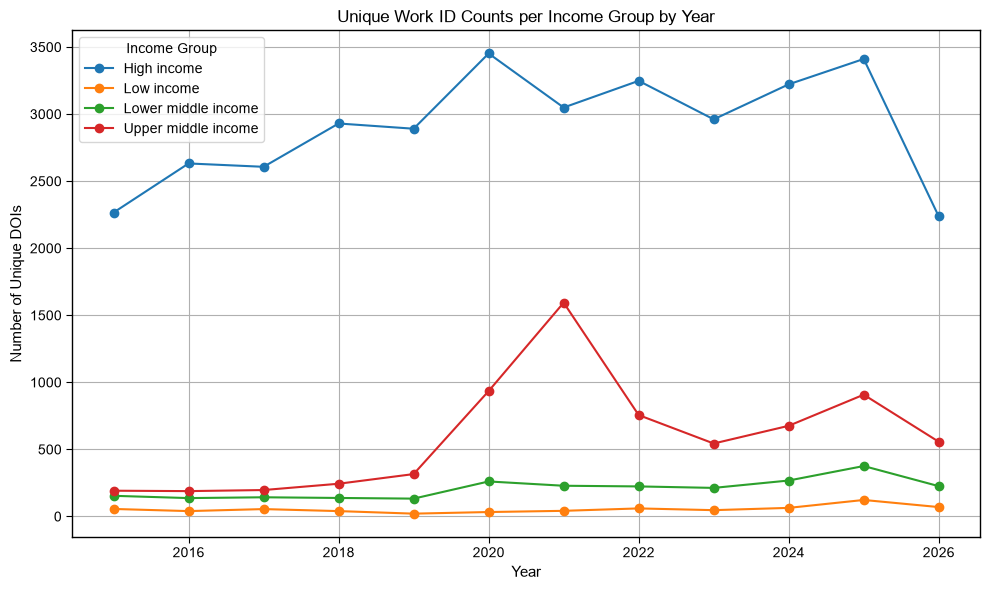

In [17]:
# Count publications per income group
counts_income = df_foranalyse.groupby(['publication_year', 'Income group'])['work_id'].nunique().reset_index()
counts_income_pivot = counts_income.pivot(index='publication_year', columns='Income group', values='work_id').fillna(0)
display(counts_income_pivot)

plt.figure(figsize=(10, 6))

for col in counts_income_pivot.columns:
    plt.plot(counts_income_pivot.index, counts_income_pivot[col], marker='o', label=col)

plt.title("Unique Work ID Counts per Income Group by Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique DOIs")
plt.legend(title="Income Group")
plt.grid(True)
plt.tight_layout()
plt.show()

Income group,High income,Low income,Lower middle income,Upper middle income
publication_year,,,,
2015,7598,48,320,544
2016,8921,49,309,571
2017,9129,107,325,598
2018,10764,76,324,919
2019,10718,26,319,1396
2020,13056,64,616,4734
2021,12832,77,621,8274
2022,12833,94,600,3483
2023,12233,113,645,2279


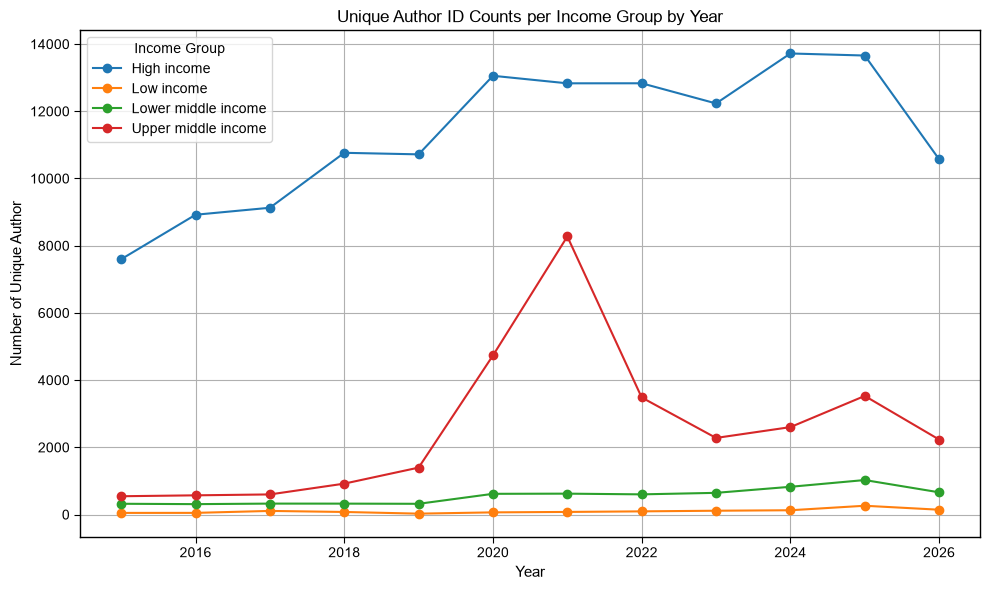

In [18]:
# Count authors per income group
counts_author = df_foranalyse.groupby(['publication_year', 'Income group'])['author_id'].nunique().reset_index()
counts_author_pivot = counts_author.pivot(index='publication_year', columns='Income group', values='author_id').fillna(0)
display(counts_author_pivot)

plt.figure(figsize=(10, 6))

for col in counts_author_pivot.columns:
    plt.plot(counts_author_pivot.index, counts_author_pivot[col], marker='o', label=col)

plt.title("Unique Author ID Counts per Income Group by Year")
plt.xlabel("Year")
plt.ylabel("Number of Unique Author")
plt.legend(title="Income Group")
plt.grid(True)
plt.tight_layout()
plt.show()

#### Global and regional publication distribution

/Users/rama-hpsr/Desktop/HPSR_QUANTI/MedEdSNA/scripts/visualization.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


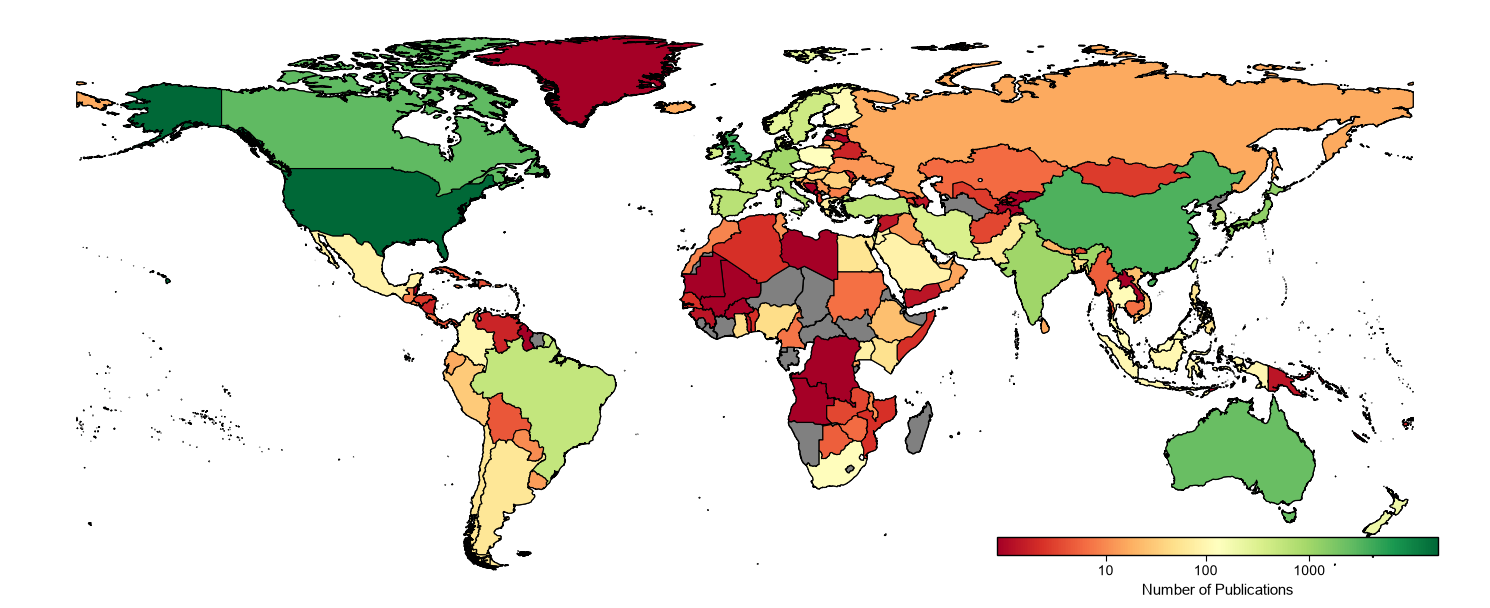

In [19]:
# Count publications per country
counts_country = df_foranalyse.groupby(['Income group', 'institution_country_code'])['work_id'].nunique().reset_index()
counts_country.columns = ['Income group', 'ISO_A2_EH', 'Publication Count']

# Merge author data with map data
world_plt = world[world['ADMIN'] != 'Antarctica']  # Exclude Antarctica
merged = world_plt.merge(counts_country, on='ISO_A2_EH', how='left')
merged['Publication Count'] = merged['Publication Count'].fillna(0)
merged['Log Publication Count'] = np.log1p(merged['Publication Count'])

# Separate subsets for plotting
has_published = merged[merged['Publication Count'] > 0]
no_published = merged[merged['Publication Count'] == 0]

visualization.plot_choropleth(world_plt, has_published, no_published)

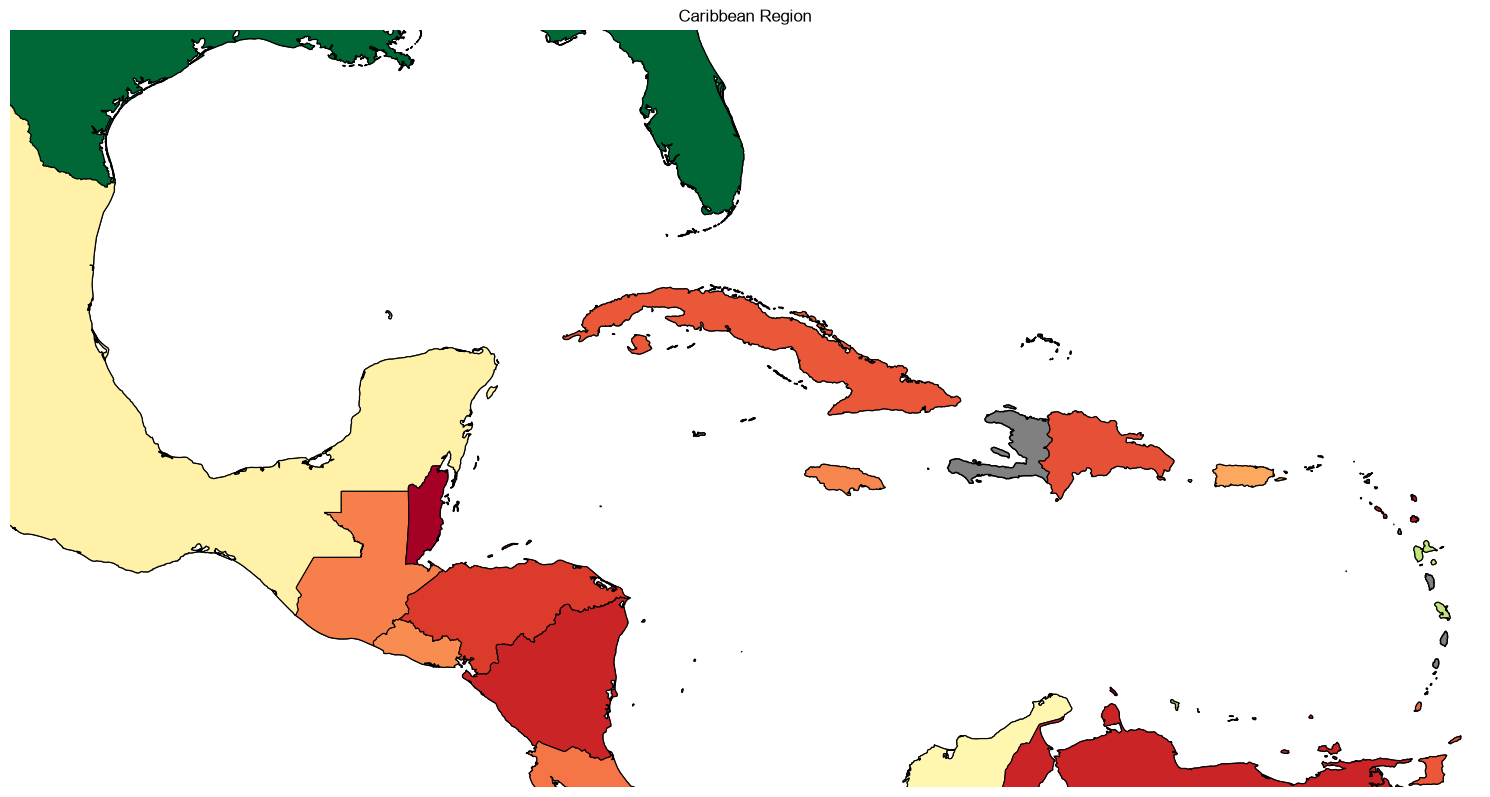

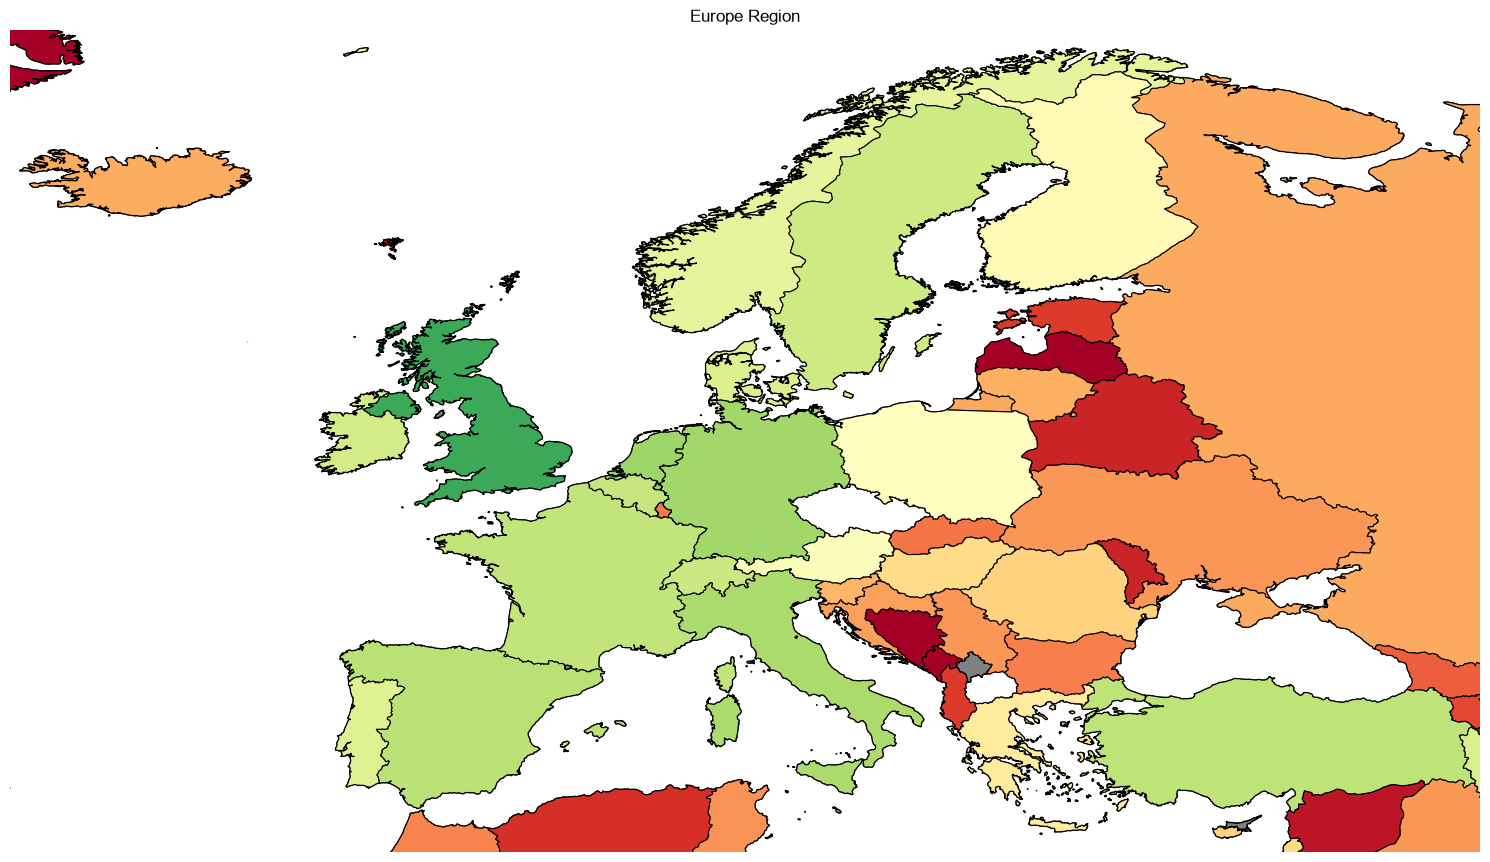

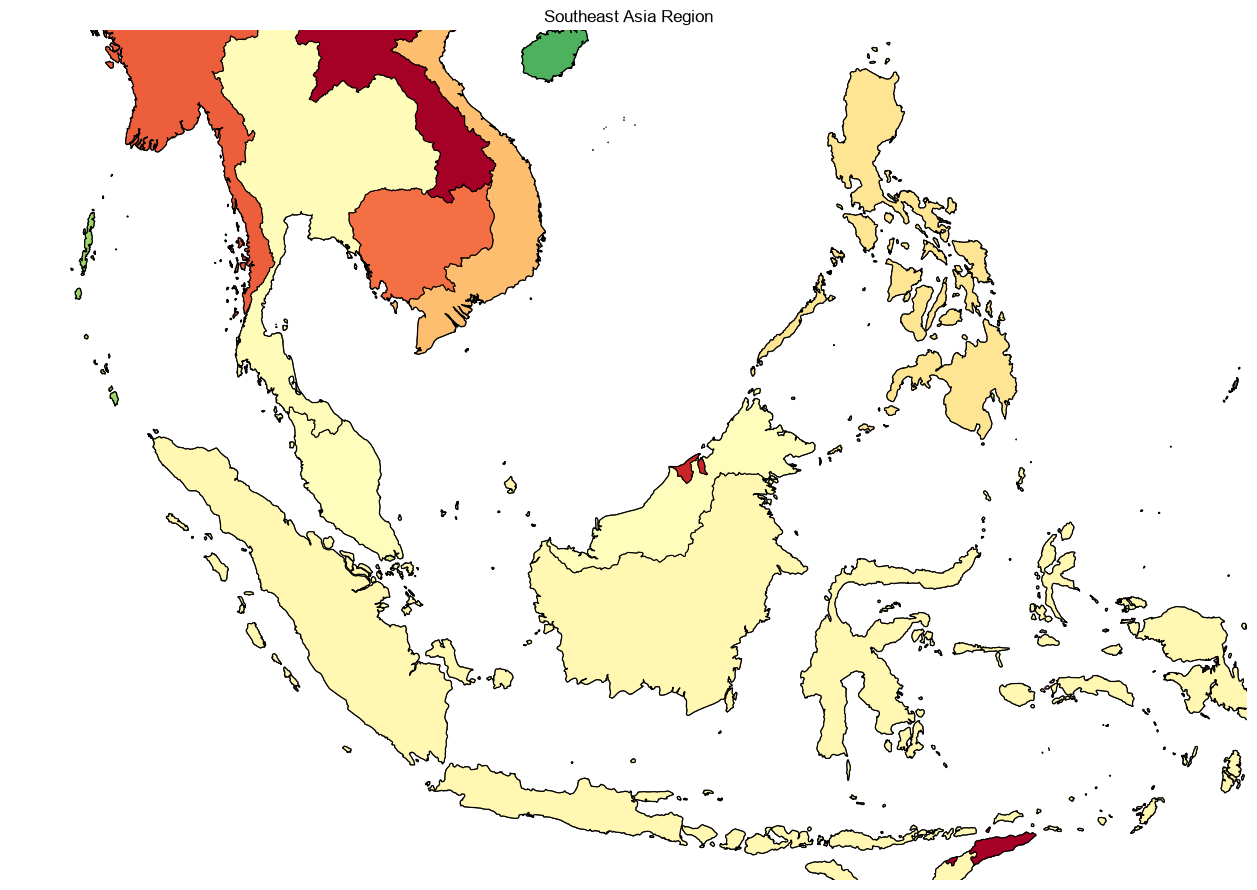

In [20]:
# Plot some region
visualization.plot_choropleth(world_plt, has_published, no_published, xlim=(-100, -60), ylim=(10, 30), title="Caribbean Region")
visualization.plot_choropleth(world_plt, has_published, no_published, xlim=(-25, 45), ylim=(34, 72), title="Europe Region")
visualization.plot_choropleth(world_plt, has_published, no_published, xlim=(90, 135), ylim=(-10, 20), title="Southeast Asia Region")

#### Collaboration patterns across income groups

In [21]:
# Pivot the collaboration patterns
df_pivot = df_foranalyse.groupby(by=['work_id', 'publication_year']).agg({
    'institution_country_code': set,
    'Region': set,
    'Income group': set
}).reset_index()

df_pivot['no_Country'] = df_pivot['institution_country_code'].apply(lambda x: len(x))
df_pivot['no_Income'] = df_pivot['Income group'].apply(lambda x: len(x))

df_pivot['count_grp'] = df_pivot.apply(
    lambda row: (
        'High only' if (row['no_Income'] == 1 and 'High income' in str(row['Income group'])) else
        'Developing only' if ('High income' not in str(row['Income group'])) else
        'Mixed'
    ),
    axis=1
)

pivot_counts = df_pivot.pivot_table(
    index='publication_year',
    columns='count_grp',
    aggfunc='size',
    fill_value=0
).reset_index()

display(pivot_counts)

count_grp,publication_year,Developing only,High only,Mixed
0,2015,164,2131,135
1,2016,189,2515,117
2,2017,183,2471,136
3,2018,201,2776,154
4,2019,277,2737,154
5,2020,926,3191,261
6,2021,1552,2785,264
7,2022,709,3014,234
8,2023,471,2708,253
9,2024,568,2893,329


#### Multi-income-group collaboration (UpSet plot)

In [22]:
# Create upset plot
df_pivot = df_foranalyse.groupby(by=['work_id', 'publication_year']).agg({
    'institution_country_code': set,
    'Region': set,
    'Income group': set
}).reset_index()
df_pivot['no_Country'] = df_pivot['institution_country_code'].apply(lambda x: len(x))
subset = df_pivot[df_pivot['no_Country'] > 1]['work_id'].drop_duplicates()
subset = pd.DataFrame(subset, columns=['work_id'])

high_income = df_foranalyse[df_foranalyse['Income group'] == 'High income']['work_id'].copy()
upper_middle_income = df_foranalyse[df_foranalyse['Income group'] == 'Upper middle income']['work_id'].copy()
lower_middle_income = df_foranalyse[df_foranalyse['Income group'] == 'Lower middle income']['work_id'].copy()
low_income = df_foranalyse[df_foranalyse['Income group'] == 'Low income']['work_id'].copy()

# Add membership flags
subset['High income'] = subset['work_id'].isin(high_income)
subset['Upper middle income'] = subset['work_id'].isin(upper_middle_income)
subset['Lower middle income'] = subset['work_id'].isin(lower_middle_income)
subset['Low income'] = subset['work_id'].isin(low_income)

upset_data = from_indicators(['High income', 'Upper middle income', 'Lower middle income', 'Low income'], subset)
display(upset_data)
# Plot
# UpSet(upset_data, subset_size='count', show_counts=True).plot()
# plt.show()

work_id  \
High income Upper middle income Lower middle income Low income                                     
True        True                False               False       https://openalex.org/W1111687354   
            False               False               False       https://openalex.org/W1123195881   
                                                    False       https://openalex.org/W1125738716   
False       True                False               False       https://openalex.org/W1129084902   
True        False               False               False       https://openalex.org/W1130697437   
...                                                                                          ...   
                                                    False        https://openalex.org/W847640221   
            True                False               False        https://openalex.org/W866172440   
            False               False               False        https://openalex.org/W925770218   
                                                    False        https://openalex.org/W976280219   
                                                    False        https://openalex.org/W987623705   

                                                                High income  \
High income Upper middle income Lower middle income Low income                
True        True                False               False              True   
            False               False               False              True   
                                                    False              True   
False       True                False               False             False   
True        False               False               False              True   
...                                                                     ...   
                                                    False              True   
            True                False               False              True   
            False               False               False              True   
                                                    False              True   
                                                    False              True   

                                                                Upper middle income  \
High income Upper middle income Lower middle income Low income                        
True        True                False               False                      True   
            False               False               False                     False   
                                                    False                     False   
False       True                False               False                      True   
True        False               False               False                     False   
...                                                                             ...   
                                                    False                     False   
            True                False               False                      True   
            False               False               False                     False   
                                                    False                     False   
                                                    False                     False   

                                                                Lower middle income  \
High income Upper middle income Lower middle income Low income                        
True        True                False               False                     False   
            False               False               False                     False   
                                                    False                     False   
False       True                False               False                     False   
True        False               False               False                     False   
...                

#### Global co-authorship network construction (2015–2024)

Build a yearly co-authorship graph per country and accumulate it into a single running network `G_all`, tracking centrality and network statistics (via `scripts/network.py`) as each year is added.

In [23]:
# Social Network Analysis
results = pd.DataFrame()
G_all = nx.Graph()

for year in range(2015, 2026):
    # Filter only the data for the current year
    df_year = df_foranalyse[df_foranalyse['publication_year'] == year]

    # Use the existing function to construct the graph for this year
    G_year = network.network_coauthorship(df_year, 'institution_country_code', id_col='work_id', node_label=['Region', 'Income group', 'FIRST_OFFI'])

    # Merge G_year into G_all
    for u, v, data in G_year.edges(data=True):
        if G_all.has_edge(u, v):
            G_all[u][v]['weight'] += data['weight']
        else:
            G_all.add_edge(u, v, weight=data['weight'])

    for node, data in G_year.nodes(data=True):
        if node not in G_all:
            G_all.add_node(node)
        for attr, value in data.items():
            G_all.nodes[node][attr] = value

    result = network.network_params(df_year, G_all, homophily_attr=['Region', 'Income group', 'FIRST_OFFI'])
    result['publication_year'] = year
    results = pd.concat([results, result], ignore_index=True)

    # Degree centrality
    deg_cent = nx.degree_centrality(G_all)
    top_deg = sorted(deg_cent.items(), key=lambda x: x[1], reverse=True)[:10]

    print("Top 10 Degree Centrality:")
    for node, val in top_deg:
        print(f"{node}: {val:.4f}")

    # Betweenness centrality
    bet_cent = nx.betweenness_centrality(G_all, normalized=True)
    top_bet = sorted(bet_cent.items(), key=lambda x: x[1], reverse=True)[:10]

    print("\nTop 10 Betweenness Centrality:")
    for node, val in top_bet:
        print(f"{node}: {val:.4f}")

    print(f'Year {year} network analysed.')

G_country = G_all
display(results)

Building coauthorship graph: 100%|██████████| 2430/2430 [00:00<00:00, 22738.68it/s]


Analysed centrality successfully.
Analysed community and participation coefficient successfully.
Analysed shortest path successfully.
Analysed homophily successfully.
Top 10 Degree Centrality:
US: 0.6974
GB: 0.4737
DE: 0.4079
IT: 0.4079
CA: 0.3684
BE: 0.3289
IN: 0.3289
AU: 0.3158
FR: 0.2895
NL: 0.2763

Top 10 Betweenness Centrality:
US: 0.3474
GB: 0.1213
IT: 0.0742
DE: 0.0580
UG: 0.0537
FR: 0.0400
CA: 0.0358
CZ: 0.0352
IE: 0.0303
ZA: 0.0287
Year 2015 network analysed.


Building coauthorship graph: 100%|██████████| 2821/2821 [00:00<00:00, 22344.55it/s]


Analysed centrality successfully.
Analysed community and participation coefficient successfully.
Analysed shortest path successfully.
Analysed homophily successfully.
Top 10 Degree Centrality:
US: 0.7396
GB: 0.5312
IT: 0.4479
CH: 0.4375
DE: 0.4271
AU: 0.4167
CA: 0.4167
KR: 0.3542
BE: 0.3333
IN: 0.3229

Top 10 Betweenness Centrality:
US: 0.3678
GB: 0.1484
IT: 0.0628
IN: 0.0554
DE: 0.0430
GH: 0.0430
CA: 0.0334
CH: 0.0280
CN: 0.0231
BR: 0.0228
Year 2016 network analysed.


Building coauthorship graph: 100%|██████████| 2790/2790 [00:00<00:00, 26604.59it/s]


...

Building coauthorship graph: 100%|██████████| 3790/3790 [00:00<00:00, 23075.97it/s]


Analysed centrality successfully.
Analysed community and participation coefficient successfully.
Analysed shortest path successfully.
Analysed homophily successfully.
Top 10 Degree Centrality:
US: 0.8301
GB: 0.6993
IN: 0.6078
CA: 0.5686
ES: 0.5556
AU: 0.5490
DE: 0.5163
IT: 0.5033
BR: 0.4837
AR: 0.4641

Top 10 Betweenness Centrality:
US: 0.1908
GB: 0.0865
IN: 0.0502
CA: 0.0424
IT: 0.0422
FR: 0.0392
AU: 0.0373
CN: 0.0367
ES: 0.0311
CH: 0.0224
Year 2024 network analysed.


Building coauthorship graph: 100%|██████████| 4175/4175 [00:00<00:00, 25118.08it/s]


Analysed centrality successfully.
Analysed community and participation coefficient successfully.
Analysed shortest path successfully.
Analysed homophily successfully.
Top 10 Degree Centrality:
US: 0.8086
GB: 0.7099
IN: 0.6543
ES: 0.5802
CA: 0.5741
AU: 0.5432
DE: 0.5123
IT: 0.5123
BR: 0.5062
UG: 0.5062

Top 10 Betweenness Centrality:
US: 0.1668
GB: 0.0851
IN: 0.0509
FR: 0.0491
NL: 0.0471
ES: 0.0418
CA: 0.0385
IT: 0.0337
CN: 0.0330
AU: 0.0307
Year 2025 network analysed.


,None,No of Publications,Single Author,Single Country,Nodes,Edges,Density,Average Clustering,Average Degree,Max Degree,Top Degree Centrality,Top Betweenness Centrality,Top Closeness Centrality,Top Eigenvector Centrality,Average Participation Coefficient,Top Participation Coefficient,No. of Communities,Modularity Score,Largest connected node,Average Shortest Path Length,Graph Diameter,Small-World Coefficient,Homophily on Region,Homophily on Income group,Homophily on FIRST_OFFI,publication_year
0,None,2430,377,1997,77,388,0.132604,0.630929,10.077922,53,0.697368,0.347382,0.738089,0.293026,0.338125,0.706612,5,0.175274,74,2.134024,4,4.700408,0.337629,0.574742,0.118557,2015
1,None,2821,362,2366,97,641,0.137672,0.624536,13.216495,71,0.739583,0.367799,0.793388,0.261688,0.372456,0.662188,4,0.158473,97,2.122423,4,4.336375,0.360374,0.588144,0.096724,2016
2,None,2790,374,2320,108,774,0.133956,0.613173,14.333333,86,0.803738,0.388751,0.835938,0.254666,0.436146,0.744170,5,0.146061,108,2.056248,4,4.450065,0.347545,0.562016,0.098191,2017
3,None,3131,356,2626,116,943,0.141379,0.610385,16.258621,93,0.808696,0.339766,0.839416,0.248182,0.398274,0.730000,4,0.159813,116,2.043478,4,4.122894,0.345705,0.518558,0.112407,2018
4,None,3168,376,2651,123,1235,0.164601,0.681105,20.081301,101,0.827869,0.295239,0.853147,0.222101,0.469336,0.721260,4,0.174420,123,1.974810,4,3.938708,0.307692,0.462348,0.108502,2019
5,None,4378,375,3666,129,1472,0.178295,0.688422,22.821705,110,0.859375,0.263938,0.876712,0.214623,0.455423,0.739592,4,0.180590,129,1.939317,4,3.676724,0.299592,0.442255,0.105299,2020
6,None,4601,283,3940,135,1651,0.182532,0.662104,24.459259,116,0.865672,0.246408,0.881579,0.212547,0.454254,0.736790,4,0.181830,135,1.948590,4,3.384341,0.322835,0.439128,0.133858,2021
7,None,3957,297,3331,142,1875,0.187294,0.659452,26.408451,120,0.851064,0.227637,0.870370,0.196047,0.466933,0.740021,4,0.181476,142,1.969933,4,3.234459,0.303467,0.418667,0.128533,2022
8,None,3432,294,2754,146,2032,0.191970,0.662171,27.835616,122,0.841379,0.200073,0.863095,0.193798,0.457088,0.766211,6,0.184228,146,1.963155,4,3.203448,0.326280,0.415354,0.148130,2023
9,None,3790,300,2986,154,2216,0.188099,0.655988,28.779221,127,0.830065,0.190754,0.854749,0.188455,0.453313,0.750000,4,0.181076,154,1.968593,4,3.221031,0.323105,0.415614,0.141697,2024


#### Network snapshots and centrality distributions

Build the two temporal network snapshots (2015–2019 and cumulative through 2024) used by the bump charts below, and inspect the distribution of centrality/participation scores across the full network.

In [24]:
# Define color map for income categories
income_colors = {
    'High income': '#1b9e77',
    'Upper middle income': '#d95f02',
    'Lower middle income': '#7570b3',
    'Low income': '#e7298a',
    'Other': '#ffffff'
}

# Keep top N countries per year for the bump charts below
top_n = 15

G_2020 = network.network_coauthorship(df_foranalyse, 'institution_country_code', id_col='work_id', filter_col='publication_year', filter_value=range(2015, 2020))
G_2024 = network.network_coauthorship(df_foranalyse, 'institution_country_code', id_col='work_id')

Building coauthorship graph: 100%|██████████| 41394/41394 [00:01<00:00, 23155.74it/s]


Building coauthorship graph: 100%|██████████| 41394/41394 [00:01<00:00, 22973.81it/s]


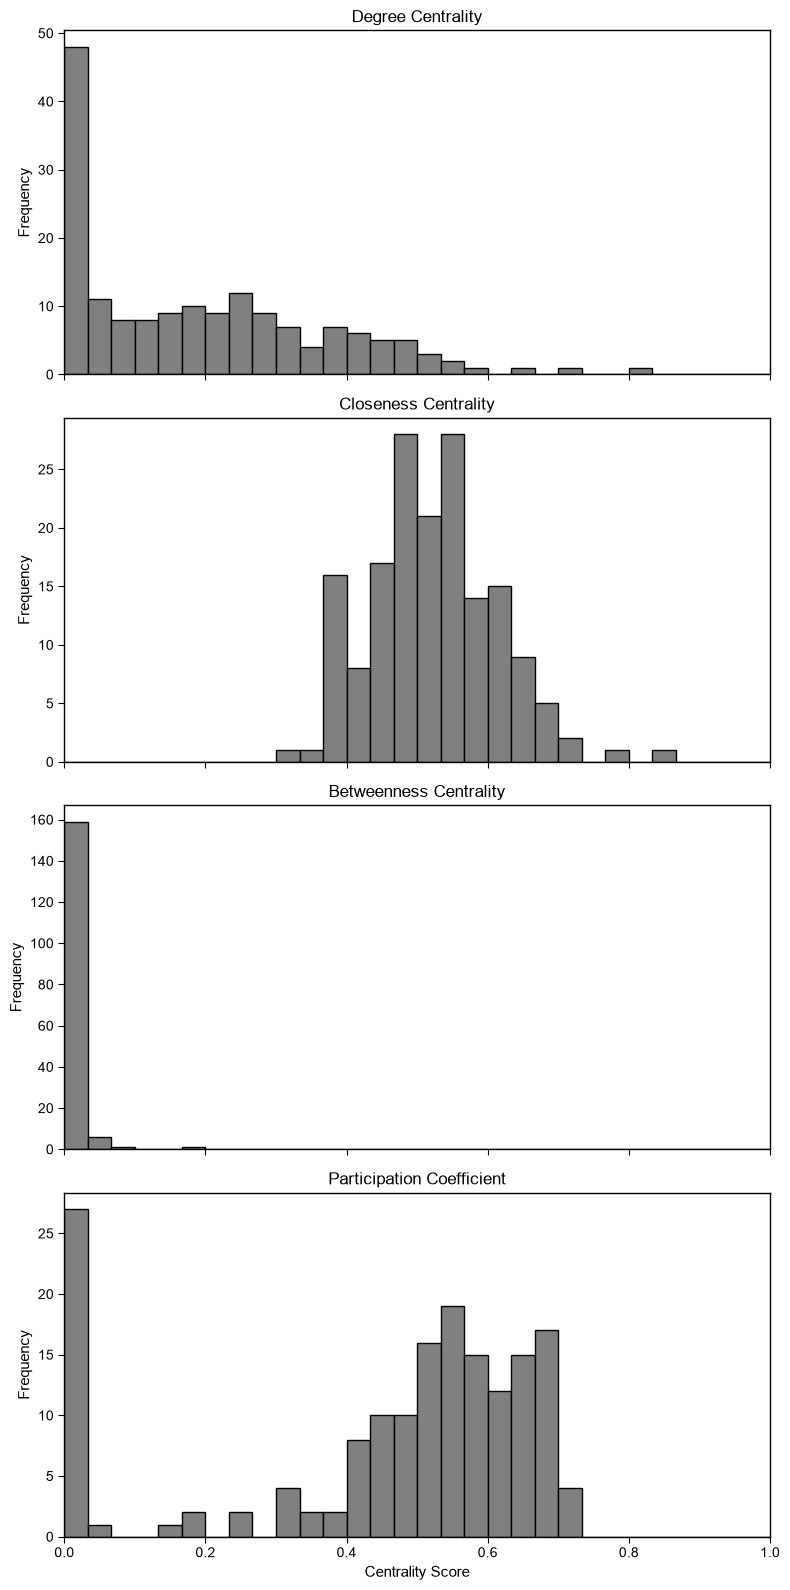

In [25]:
G = network.network_coauthorship(df_foranalyse, 'institution_country_code', id_col='work_id')

deg = nx.degree_centrality(G)
cls = nx.closeness_centrality(G)
btw = nx.betweenness_centrality(G)

partition = community_louvain.best_partition(G, random_state=42)
pc = network.participation_coefficient(G, partition)

# Convert to lists
deg_values = list(deg.values())
cls_values = list(cls.values())
btw_values = list(btw.values())
part_values = list(pc.values())

# Plotting
fig, axs = plt.subplots(4, 1, figsize=(8, 16), sharex=False)
bins = np.linspace(0, 1, 31)  # 30 equal-width bins between 0 and 1

# Degree centrality
axs[0].hist(deg_values, bins=bins, color='grey', edgecolor='black')
axs[0].set_title('Degree Centrality', fontsize=12)
axs[0].set_ylabel('Frequency')
axs[0].set_xlim(0,1)
axs[0].tick_params(labelbottom=False)  # Hide x-axis labels

# Closeness centrality
axs[1].hist(cls_values, bins=bins, color='grey', edgecolor='black')
axs[1].set_title('Closeness Centrality', fontsize=12)
axs[1].set_ylabel('Frequency')
axs[1].set_xlim(0,1)
axs[1].tick_params(labelbottom=False)  # Hide x-axis labels

# Betweenness centrality
axs[2].hist(btw_values, bins=bins, color='grey', edgecolor='black')
axs[2].set_title('Betweenness Centrality', fontsize=12)
axs[2].set_ylabel('Frequency')
axs[2].set_xlim(0,1)
axs[2].tick_params(labelbottom=False)  # Hide x-axis labels

# Participation coefficient
axs[3].hist(part_values, bins=bins, color='grey', edgecolor='black')
axs[3].set_title('Participation Coefficient', fontsize=12)
axs[3].set_ylabel('Frequency')
axs[3].set_xlabel('Centrality Score')
axs[3].set_xlim(0,1)

# Tight layout
plt.tight_layout()
plt.show()

#### Bump charts: centrality rank shifts, 2015 vs 2024

For each centrality measure, rank the top countries in the 2015–2019 snapshot (`G_2020`) and the cumulative 2024 snapshot (`G_2024`), and plot how their rank shifted using `visualization.plot_bump_chart`.

In [ ]:
# Degree centrality
deg_2015 = nx.degree_centrality(G_2020)
deg_2024 = nx.degree_centrality(G_2024)
visualization.plot_bump_chart(deg_2015, deg_2024, income_gr, income_colors, top_n=10)

In [ ]:
# Closeness centrality
cls_2015 = nx.closeness_centrality(G_2020)
cls_2024 = nx.closeness_centrality(G_2024)
visualization.plot_bump_chart(cls_2015, cls_2024, income_gr, income_colors, top_n=top_n)

In [ ]:
# Betweenness centrality
btw_2015 = nx.betweenness_centrality(G_2020)
btw_2024 = nx.betweenness_centrality(G_2024)
visualization.plot_bump_chart(btw_2015, btw_2024, income_gr, income_colors, top_n=top_n)

In [ ]:
# Participation coefficient
partition_2015 = community_louvain.best_partition(G_2020, random_state=42)
partition_2024 = community_louvain.best_partition(G_2024, random_state=42)

pc_2015 = network.participation_coefficient(G_2020, partition_2015)
pc_2024 = network.participation_coefficient(G_2024, partition_2024)

visualization.plot_bump_chart(pc_2015, pc_2024, income_gr, income_colors, top_n=top_n)

#### Co-authorship network on the world map

Overlay the co-authorship network on the world map (via `visualization.plot_network_on_map`), first for all publications, then restricted to publications with a low-income first author.

Building coauthorship graph: 100%|██████████| 41394/41394 [00:01<00:00, 23035.44it/s]


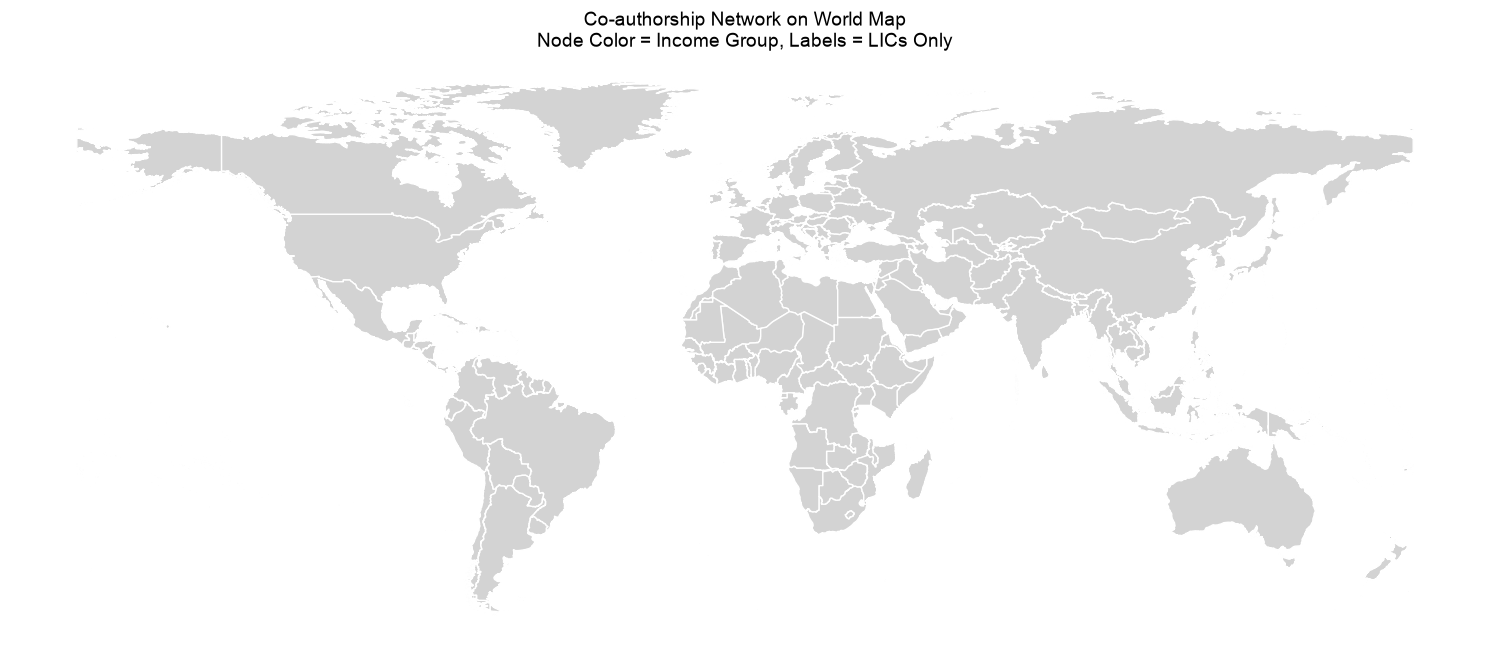

In [ ]:
df = df_foranalyse.copy()

G_lic = network.network_coauthorship(df, 'institution_country_code', id_col='work_id')
country_income = df[['institution_country_code', 'Income group']].drop_duplicates().set_index('institution_country_code')['Income group'].to_dict()
for node in G_lic.nodes:
    G_lic.nodes[node]['Income group'] = country_income.get(node, 'Other')  # default to 'Other' if missing

visualization.plot_network_on_map(
    G_lic, world, income_colors, edge_scale=0.05,
    title='Co-authorship Network on World Map\nNode Color = Income Group, Labels = LICs Only'
)

In [ ]:
df = df_foranalyse.copy()
lic_set = set(df[(df['Income group'] == 'Low income') & (df['author_position'] == 'first')]['work_id'])
df_lic = df[df['work_id'].isin(lic_set)]

G_lic = network.network_coauthorship(df_lic, 'institution_country_code', id_col='work_id')
country_income = df_lic[['institution_country_code', 'Income group']].drop_duplicates().set_index('institution_country_code')['Income group'].to_dict()
for node in G_lic.nodes:
    G_lic.nodes[node]['Income group'] = country_income.get(node, 'Other')  # default to 'Other' if missing

visualization.plot_network_on_map(
    G_lic, world, income_colors, edge_scale=0.5, node_scale=10,
    title='Co-authorship Network on World Map\nNode Color = Income Group, Labels = LICs Only'
)